# 1.2 KPI profiling

Perfilamiento de los indicadores contra `catalogo_indicadores` a partir de hipótesis: (1) documentación en el catálogo,
(2) frentes, (3) cobertura en el tiempo, (4) fórmula, tope y escala de `Cumplimiento`, (5) reproducibilidad. Cierra con una ficha por indicador.

Artefactos persistidos: ficha de indicadores para revisión humana; es la base de las reglas de negocio por indicador del ETL.

| Artefacto | Ruta |
|---|---|
| Entrada | `data/0_source/KPIS_historico.xlsx` (hojas `query`, `catalogo_indicadores`) |
| Salida ficha | `docs/ficha_indicadores.csv` |


In [1]:
from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 50)

SOURCE_PATH = Path("../../data/0_source/KPIS_historico.xlsx")
FICHA_PATH = Path("../../docs/ficha_indicadores.csv")

COLUMNAS_NUMERICAS = ["Resultado", "Meta", "Cumplimiento"]
TOLERANCIA_ABS, TOLERANCIA_REL = 1e-6, 1e-5  # estricta: el cumplimiento viene con precisión completa

COLOR = {"amarillo": "#fdda24", "verde": "#00c389", "morado": "#9063cd", "naranja": "#ff7f41",
         "rosado": "#f5b6cd", "azul": "#59cbe8", "negro": "#2a2625", "gris": "#9e9a99"}
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": COLOR["gris"], "axes.labelcolor": COLOR["negro"],
                     "xtick.color": COLOR["negro"], "ytick.color": COLOR["negro"], "axes.spines.top": False, "axes.spines.right": False})
RAMPA = LinearSegmentedColormap.from_list("marca", [COLOR["amarillo"], COLOR["verde"], COLOR["azul"], COLOR["morado"]])

HIPOTESIS = []


def registrar_hipotesis(codigo, enunciado, resultado, evidencia):
    """resultado: 'se cumple' | 'no se cumple' | 'parcial'."""
    HIPOTESIS.append({"hipotesis": codigo, "enunciado": enunciado, "resultado": resultado, "evidencia": evidencia})
    print(f"{codigo} | {resultado.upper()} | {evidencia}")


def sin_tildes(s):
    return s.str.strip().str.lower().map(
        lambda t: unicodedata.normalize("NFKD", t).encode("ascii", "ignore").decode() if pd.notna(t) else t
    )


# Solo se quitan duplicados exactos para no contar dos veces la misma fila
query = pd.read_excel(SOURCE_PATH, sheet_name="query", dtype=str).drop_duplicates()
for col in COLUMNAS_NUMERICAS:
    query[col] = pd.to_numeric(query[col])
query["indicador_norm"] = sin_tildes(query.Indicador)

cat_ind = pd.read_excel(SOURCE_PATH, sheet_name="catalogo_indicadores", dtype=str)
cat_ind.columns = ["frente_catalogo", "indicador_catalogo", "definicion", "unidad"]
cat_ind["indicador_norm"] = sin_tildes(cat_ind.indicador_catalogo)
print("query | filas sin duplicados exactos:", len(query), "| catálogo:", len(cat_ind), "indicadores")


query | filas sin duplicados exactos: 13006 | catálogo: 13 indicadores


## H09. Todos los indicadores de los datos están documentados en `catalogo_indicadores`

El cruce usa el nombre normalizado (minúsculas, sin tildes) para no castigar diferencias de escritura.


In [2]:
indicadores = (
    query.groupby("Indicador")
    .agg(frente=("Frente", lambda s: " / ".join(sorted(s.unique()))), indicador_norm=("indicador_norm", "first"),
         filas=("Corte", "size"))
    .reset_index()
    .merge(cat_ind, on="indicador_norm", how="left")
)
indicadores["en_catalogo"] = indicadores.indicador_catalogo.notna()
no_doc = indicadores[~indicadores.en_catalogo]
escritura_distinta = indicadores[indicadores.en_catalogo & (indicadores.Indicador != indicadores.indicador_catalogo)]

display(no_doc[["Indicador", "frente", "filas"]])
registrar_hipotesis(
    "H09", "Todos los indicadores de los datos están en el catálogo",
    "se cumple" if no_doc.empty else "no se cumple",
    f"{len(no_doc)} de {len(indicadores)} indicadores sin documentar ({no_doc.filas.sum() / len(query):.0%} de filas); "
    f"escritos distinto: {', '.join(escritura_distinta.Indicador + ' vs ' + escritura_distinta.indicador_catalogo)}",
)


,Indicador,frente,filas
0,Adopción,Modelos de trabajo y Agilidad / Talento + Agil...,1368
2,Apps modernizadas,TI,103
3,Brecha Ingresos Gastos,Financiero,268
6,Cumplimiento presupuestal,Financiero,324
8,Ejecución Presupuestal,Financiero,341
11,Gestión del Gasto,Financiero,20
13,"Impactos a clientes activos por fricciones, qu...",Excelencia operativa,142
14,Incidentes,TI,588
15,Jaws de Ciclo,Financiero,11
17,Neon,TI,104


H09 | NO SE CUMPLE | 14 de 25 indicadores sin documentar (54% de filas); escritos distinto: Pérdida esperada por fraude vs Perdida esperada por fraude


## H10. Todos los indicadores del catálogo tienen mediciones


In [3]:
sin_datos = cat_ind[~cat_ind.indicador_norm.isin(query.indicador_norm)]
registrar_hipotesis(
    "H10", "Todos los indicadores del catálogo tienen mediciones",
    "se cumple" if sin_datos.empty else "no se cumple",
    f"{len(sin_datos)} sin mediciones: {', '.join(sin_datos.indicador_catalogo)}",
)


H10 | NO SE CUMPLE | 2 sin mediciones: Adopción de la metodologia, Productividad

## H11. Los nombres de frente coinciden entre datos y catálogo, y H12. cada indicador pertenece a un solo frente


In [4]:
frentes_datos, frentes_cat = set(query.Frente), set(cat_ind.frente_catalogo)
display(query.groupby("Frente").Corte.agg(["min", "max", "size"]))
registrar_hipotesis(
    "H11", "Los nombres de frente coinciden entre datos y catálogo",
    "se cumple" if frentes_datos == frentes_cat else "no se cumple",
    f"solo en datos: {sorted(frentes_datos - frentes_cat)}; solo en catálogo: {sorted(frentes_cat - frentes_datos)}; "
    "'Modeos…' (error tipográfico) está en ambos",
)

multifrente = query.groupby("Indicador").Frente.unique()
multifrente = multifrente[multifrente.str.len() > 1]
registrar_hipotesis(
    "H12", "Cada indicador pertenece a un solo frente",
    "se cumple" if multifrente.empty else "no se cumple",
    f"{len(multifrente)} indicadores en más de un frente ({', '.join(multifrente.index)}): "
    "el frente 'Talento + Agilidad' (2023-2024) se renombró a 'Modelos de trabajo y Agilidad' (2025) y a 'Modeos…' (2026)",
)


,min,max,size
Frente,,,
Excelencia operativa,202309,202608,2263
Experiencia,202601,202607,199
Financiero,202308,202606,2091
Modelos de trabajo y Agilidad,202501,202509,1603
Modeos de trabajo y Agilidad,202601,202608,417
Regulatorio,202310,202606,641
TI,202309,202608,3120
Talento + Agilidad,202301,202412,2672


H11 | NO SE CUMPLE | solo en datos: ['Talento + Agilidad']; solo en catálogo: []; 'Modeos…' (error tipográfico) está en ambos
H12 | NO SE CUMPLE | 3 indicadores en más de un frente (Adopción, Percepción, Talento + Agilidad): el frente 'Talento + Agilidad' (2023-2024) se renombró a 'Modelos de trabajo y Agilidad' (2025) y a 'Modeos…' (2026)


## H13. Cada indicador se mide durante todo el periodo


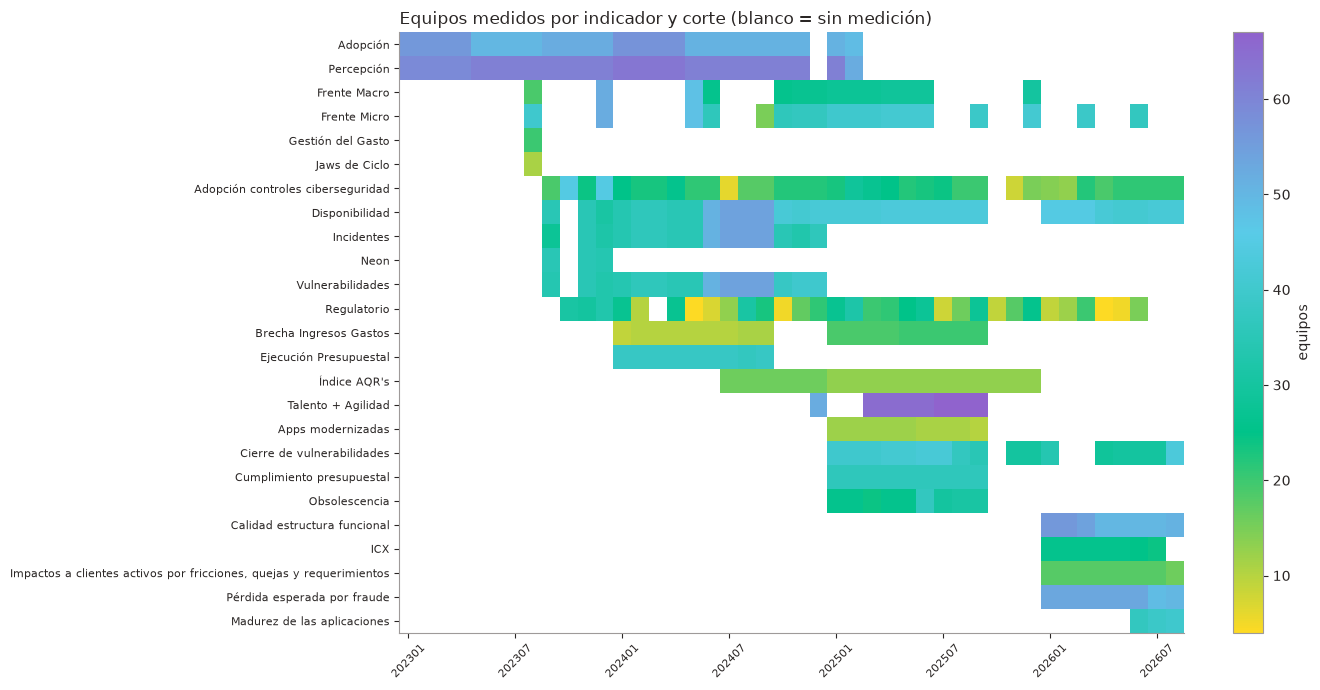

H13 | NO SE CUMPLE | ningún indicador cubre los 44 cortes (máximo 35); 2 indicadores de un solo corte; Percepción/Adopción se reemplazan por Talento + Agilidad desde 202412


In [5]:
cobertura = query.groupby(["Indicador", "Corte"]).Codigo_EQU.nunique().unstack(fill_value=0)
cobertura = cobertura.loc[query.groupby("Indicador").Corte.min().sort_values().index]

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(cobertura.where(cobertura > 0), aspect="auto", cmap=RAMPA)
ax.set_yticks(range(len(cobertura)), cobertura.index, fontsize=8)
ticks = [i for i, c in enumerate(cobertura.columns) if c.endswith(("01", "07"))]
ax.set_xticks(ticks, [cobertura.columns[i] for i in ticks], rotation=45, fontsize=8)
ax.set_title("Equipos medidos por indicador y corte (blanco = sin medición)", loc="left", color=COLOR["negro"])
fig.colorbar(im, ax=ax, label="equipos")
plt.tight_layout()
plt.show()

resumen_cobertura = query.groupby("Indicador").agg(
    primer_corte=("Corte", "min"), ultimo_corte=("Corte", "max"), cortes=("Corte", "nunique"), equipos=("Codigo_EQU", "nunique"),
)
total_cortes = query.Corte.nunique()
registrar_hipotesis(
    "H13", "Cada indicador se mide durante todo el periodo",
    "se cumple" if resumen_cobertura.cortes.eq(total_cortes).all() else "no se cumple",
    f"ningún indicador cubre los {total_cortes} cortes (máximo {resumen_cobertura.cortes.max()}); "
    f"{resumen_cobertura.cortes.eq(1).sum()} indicadores de un solo corte; Percepción/Adopción se reemplazan por Talento + Agilidad desde 202412",
)


## H14. `Cumplimiento = Resultado / Meta` en todos los indicadores

Para cada indicador se prueba qué fórmula reproduce el `Cumplimiento` reportado, con y sin tope:

| Fórmula | Expresión | Sentido implícito |
|---|---|---|
| `ratio` | Resultado / Meta | mayor es mejor |
| `inverso` | Meta / Resultado | menor es mejor |
| `dos_menos_ratio` | 2 − Resultado / Meta | menor es mejor |
| `uno_mas_diferencia` | 1 + (Resultado − Meta) | mayor es mejor (diferencia absoluta) |
| `uno_menos_diferencia` | 1 − (Resultado − Meta) | menor es mejor (diferencia absoluta) |
| `escala` | Resultado | puntaje bruto |

Topes probados: sin tope, [0, 1] y [0, 1.2]. Gana la combinación que explica más filas; ante empate, la más simple y la de mayor prioridad en la tabla.


In [6]:
# El orden define la prioridad ante empates (con Meta = 1, Resultado y Resultado/Meta coinciden)
FORMULAS = {
    "ratio": (lambda r, m: r / m, "mayor es mejor"),
    "inverso": (lambda r, m: m / r, "menor es mejor"),
    "dos_menos_ratio": (lambda r, m: 2 - r / m, "menor es mejor"),
    "uno_mas_diferencia": (lambda r, m: 1 + (r - m), "mayor es mejor"),
    "uno_menos_diferencia": (lambda r, m: 1 - (r - m), "menor es mejor"),
    "escala": (lambda r, m: r, "escala"),
}
PRIORIDAD = {nombre: i for i, nombre in enumerate(FORMULAS)}
TOPES = {"sin_tope": None, "tope_1": (0, 1), "tope_1_2": (0, 1.2)}


def coincidencias(g):
    g = g.dropna(subset=COLUMNAS_NUMERICAS)
    r, m, c = g.Resultado.to_numpy(), g.Meta.to_numpy(), g.Cumplimiento.to_numpy()
    filas = {}
    with np.errstate(divide="ignore", invalid="ignore"):
        for nombre_f, (f, _) in FORMULAS.items():
            base = f(r, m)
            # 0/0 lo resuelve el negocio como cumplimiento máximo; se trata como inf para que el tope lo capture
            base = np.where(np.isnan(base) & (r == m), np.inf, base)
            for nombre_t, tope in TOPES.items():
                pred = base if tope is None else np.clip(base, *tope)
                filas[(nombre_f, nombre_t)] = np.isclose(pred, c, atol=TOLERANCIA_ABS, rtol=TOLERANCIA_REL)
    return g.index, filas


registros, explicacion = [], {}
for indicador, g in query.groupby("Indicador"):
    idx, filas = coincidencias(g)
    if len(idx) == 0:
        continue
    pct = {k: v.mean() for k, v in filas.items()}
    mejor = max(pct, key=lambda k: (round(pct[k], 3), -(k[1] != "sin_tope"), -PRIORIDAD[k[0]]))
    alguna = np.logical_or.reduce(list(filas.values()))
    explicacion[indicador] = pd.Series(alguna, index=idx)
    registros.append({
        "Indicador": indicador, "filas_evaluables": len(idx),
        "formula_inferida": mejor[0], "tope_inferido": mejor[1], "sentido_inferido": FORMULAS[mejor[0]][1],
        "pct_explicado_formula": round(pct[mejor], 3), "pct_explicado_alguna": round(alguna.mean(), 3),
    })

inferencia = pd.DataFrame(registros).set_index("Indicador").sort_values("pct_explicado_formula")
display(inferencia)

no_ratio = inferencia[inferencia.formula_inferida != "ratio"]
registrar_hipotesis(
    "H14", "Cumplimiento = Resultado / Meta en todos los indicadores",
    "se cumple" if no_ratio.empty else "no se cumple",
    f"{len(no_ratio)} indicadores usan otra fórmula: "
    + ", ".join(f"{i} ({r.formula_inferida if r.pct_explicado_formula >= 0.6 else 'no reproducible'})" for i, r in no_ratio.iterrows()),
)


,filas_evaluables,formula_inferida,tope_inferido,sentido_inferido,pct_explicado_formula,pct_explicado_alguna
Indicador,,,,,,
Brecha Ingresos Gastos,268,uno_menos_diferencia,tope_1_2,menor es mejor,0.194,0.396
Pérdida esperada por fraude,417,inverso,tope_1_2,menor es mejor,0.254,0.254
Índice AQR's,283,escala,tope_1_2,escala,0.396,0.555
Incidentes,483,ratio,sin_tope,mayor es mejor,0.468,0.478
Vulnerabilidades,532,ratio,sin_tope,mayor es mejor,0.731,0.731
Disponibilidad,1243,ratio,sin_tope,mayor es mejor,0.767,0.768
"Impactos a clientes activos por fricciones, quejas y requerimientos",142,escala,sin_tope,escala,0.810,0.845
Frente Macro,354,ratio,sin_tope,mayor es mejor,0.932,0.935
Frente Micro,631,ratio,sin_tope,mayor es mejor,0.945,0.945


H14 | NO SE CUMPLE | 10 indicadores usan otra fórmula: Brecha Ingresos Gastos (no reproducible), Pérdida esperada por fraude (no reproducible), Índice AQR's (no reproducible), Impactos a clientes activos por fricciones, quejas y requerimientos (escala), Obsolescencia (inverso), Jaws de Ciclo (uno_mas_diferencia), Gestión del Gasto (uno_menos_diferencia), Adopción (escala), Percepción (escala), Talento + Agilidad (escala)


## H15. `Cumplimiento` tiene un tope común de 1.2


In [7]:
topes = inferencia[inferencia.formula_inferida != "escala"].tope_inferido.value_counts()
sobre_tope = query[(query.Cumplimiento > 1.2 + TOLERANCIA_ABS) & ~query.Indicador.isin(inferencia.index[inferencia.formula_inferida == "escala"])]
registrar_hipotesis(
    "H15", "Cumplimiento tiene un tope común de 1.2",
    "no se cumple" if topes.size > 1 else "se cumple",
    f"topes inferidos: {topes.to_dict()}; {len(sobre_tope)} filas sobre 1.2 en "
    f"{sobre_tope.Indicador.nunique()} indicadores (máx. {sobre_tope.Cumplimiento.max():.1f})",
)


H15 | NO SE CUMPLE | topes inferidos: {'sin_tope': 14, 'tope_1_2': 5, 'tope_1': 1}; 55 filas sobre 1.2 en 6 indicadores (máx. 155.4)


## H16. La escala (Meta) de cada indicador es estable en el tiempo


In [8]:
escala = inferencia.index[inferencia.formula_inferida == "escala"]
metas_encuesta = query[query.Indicador.isin(["Percepción", "Adopción"])].groupby(["Indicador", "Meta"]).Corte.agg(["min", "max", "size"])
display(metas_encuesta)
aqr = query[query.Indicador == "Índice AQR's"].Meta
registrar_hipotesis(
    "H16", "La escala (Meta) de cada indicador es estable en el tiempo",
    "no se cumple",
    "Percepción/Adopción cambian de meta 10 (2023) a 4 (2024) y 5 (2025); "
    f"Índice AQR's mezcla metas de {aqr.min():.2f} a {aqr.max():,.0f} (otra unidad)",
)


min     max  size
Indicador  Meta                      
Adopción   4.0   202401  202501   636
           5.0   202502  202502   100
           10.0  202301  202312   632
Percepción 4.0   202401  202501   740
           5.0   202502  202502   874
           10.0  202301  202312   724

H16 | NO SE CUMPLE | Percepción/Adopción cambian de meta 10 (2023) a 4 (2024) y 5 (2025); Índice AQR's mezcla metas de 0.06 a 15,627,925 (otra unidad)


## H17. `Cumplimiento` siempre es reproducible desde `Resultado` y `Meta`


In [9]:
no_explicadas = pd.concat([s[~s] for s in explicacion.values()]).index
no_explicadas = query.loc[no_explicadas, ["Indicador", "Corte", "Codigo_EQU", "Resultado", "Meta", "Cumplimiento"]]
display(no_explicadas.Indicador.value_counts().rename("filas").to_frame().T)

# Mismo Cumplimiento con muchos Resultados distintos = valor copiado, no medido
copiados = (no_explicadas.groupby(["Indicador", "Cumplimiento"]).Resultado.agg(["size", "nunique"])
            .query("size >= 10 and nunique >= 5").sort_values("size", ascending=False))
display(copiados)
total_evaluables = sum(len(s) for s in explicacion.values())
registrar_hipotesis(
    "H17", "Cumplimiento siempre es reproducible desde Resultado y Meta",
    "no se cumple",
    f"{len(no_explicadas)} filas ({len(no_explicadas) / total_evaluables:.1%}) sin fórmula que las explique; "
    "el valor 1.014683 se repite en Disponibilidad e Incidentes con cientos de resultados distintos; "
    "Incidentes 202408 tiene 19 equipos con Cumplimiento 155.42; Pérdida esperada y AQR's usan tablas escalonadas",
)


Indicador,Pérdida esperada por fraude,Disponibilidad,Incidentes,Brecha Ingresos Gastos,Vulnerabilidades,Índice AQR's,Frente Micro,Frente Macro,"Impactos a clientes activos por fricciones, quejas y requerimientos",Adopción controles ciberseguridad,Obsolescencia,Regulatorio,ICX
filas,311,288,252,162,143,126,35,23,22,18,2,2,1


size  nunique
Indicador              Cumplimiento               
Disponibilidad         1.014683       286      272
Incidentes             1.014683       130      103
Índice AQR's           0.500000        81       79
                       0.800000        42       27
Brecha Ingresos Gastos 0.800000        33       33
Incidentes             155.421480      19       17
Vulnerabilidades       0.000000        13       13

H17 | NO SE CUMPLE | 1385 filas (11.1%) sin fórmula que las explique; el valor 1.014683 se repite en Disponibilidad e Incidentes con cientos de resultados distintos; Incidentes 202408 tiene 19 equipos con Cumplimiento 155.42; Pérdida esperada y AQR's usan tablas escalonadas


## Distribución de `Cumplimiento` en indicadores tipo ratio


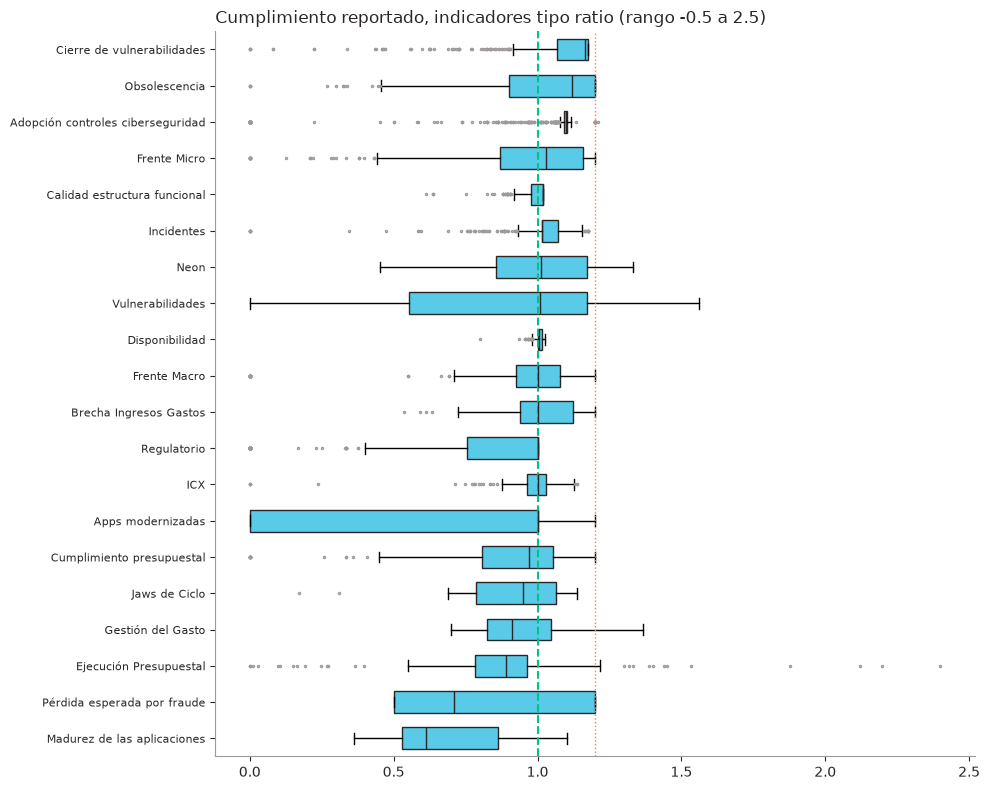

In [10]:
datos = query.dropna(subset=["Cumplimiento"])
# Solo para graficar: se excluyen indicadores de escala y extremos (analizados en H15-H17)
datos = datos[~datos.Indicador.isin(escala) & datos.Cumplimiento.between(-0.5, 2.5)]
orden = datos.groupby("Indicador").Cumplimiento.median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot([datos.loc[datos.Indicador == i, "Cumplimiento"] for i in orden], orientation="horizontal", widths=0.6,
           patch_artist=True, boxprops=dict(facecolor=COLOR["azul"], color=COLOR["negro"]),
           medianprops=dict(color=COLOR["negro"]), flierprops=dict(marker=".", markersize=3, markeredgecolor=COLOR["gris"]))
ax.set_yticks(range(1, len(orden) + 1), orden, fontsize=8)
ax.axvline(1, color=COLOR["verde"], lw=1.5, ls="--")
ax.axvline(1.2, color=COLOR["naranja"], lw=1, ls=":")
ax.set_title("Cumplimiento reportado, indicadores tipo ratio (rango -0.5 a 2.5)", loc="left", color=COLOR["negro"])
plt.tight_layout()
plt.show()


## Ficha por indicador


In [11]:
perfil = query.groupby("Indicador").agg(
    meta_min=("Meta", "min"), meta_max=("Meta", "max"),
    cumpl_mediana=("Cumplimiento", "median"), cumpl_valores_distintos=("Cumplimiento", "nunique"),
)
ficha = (
    indicadores.set_index("Indicador")[["frente", "filas", "en_catalogo", "unidad", "definicion"]]
    .join(resumen_cobertura).join(inferencia).join(perfil)
    .reset_index().sort_values(["frente", "Indicador"])
)
escalonada = ficha.pct_explicado_formula.lt(0.6) & ficha.cumpl_valores_distintos.lt(0.1 * ficha.filas)
ficha["observacion"] = np.select(
    [escalonada, ficha.formula_inferida.eq("escala") & ficha.meta_min.ge(3), ficha.formula_inferida.eq("escala"),
     ficha.pct_explicado_formula.lt(0.8), ficha.cortes.eq(1)],
    ["Probable tabla escalonada: usar cumplimiento reportado",
     "Puntaje de escala (encuesta): requiere normalizar contra la meta",
     "Resultado ya viene expresado como cumplimiento",
     "Fórmula parcialmente reproducible: revisar filas no explicadas",
     "Indicador de un solo corte: poco útil para tendencia"],
    default="Fórmula reproducible",
)
ficha.loc[escalonada, ["formula_inferida", "tope_inferido", "sentido_inferido"]] = ["escalonada", "no aplica", "no inferible"]
FICHA_PATH.parent.mkdir(parents=True, exist_ok=True)
ficha.round(4).to_csv(FICHA_PATH, index=False, encoding="utf-8-sig")
print("ficha | indicadores:", len(ficha), "| guardado:", FICHA_PATH)
display(ficha[["Indicador", "frente", "en_catalogo", "cortes", "formula_inferida", "tope_inferido", "sentido_inferido",
               "pct_explicado_formula", "observacion"]])


ficha | indicadores: 25 | guardado: ..\..\docs\ficha_indicadores.csv


,Indicador,frente,en_catalogo,cortes,formula_inferida,tope_inferido,sentido_inferido,pct_explicado_formula,observacion
1,Adopción controles ciberseguridad,Excelencia operativa,True,35,ratio,sin_tope,mayor es mejor,0.977,Fórmula reproducible
5,Cierre de vulnerabilidades,Excelencia operativa,True,17,ratio,sin_tope,mayor es mejor,1.000,Fórmula reproducible
13,"Impactos a clientes activos por fricciones, qu...",Excelencia operativa,False,8,escala,sin_tope,escala,0.810,Resultado ya viene expresado como cumplimiento
20,Pérdida esperada por fraude,Excelencia operativa,True,8,escalonada,no aplica,no inferible,0.254,Probable tabla escalonada: usar cumplimiento r...
24,Índice AQR's,Excelencia operativa,True,18,escalonada,no aplica,no inferible,0.396,Probable tabla escalonada: usar cumplimiento r...
12,ICX,Experiencia,True,7,ratio,sin_tope,mayor es mejor,0.995,Fórmula reproducible
3,Brecha Ingresos Gastos,Financiero,False,18,uno_menos_diferencia,tope_1_2,menor es mejor,0.194,Fórmula parcialmente reproducible: revisar fil...
6,Cumplimiento presupuestal,Financiero,False,9,ratio,tope_1_2,mayor es mejor,1.000,Fórmula reproducible
8,Ejecución Presupuestal,Financiero,False,9,ratio,sin_tope,mayor es mejor,1.000,Fórmula reproducible
9,Frente Macro,Financiero,True,14,ratio,sin_tope,mayor es mejor,0.932,Fórmula reproducible


## Resumen de hipótesis


In [12]:
display(pd.DataFrame(HIPOTESIS).set_index("hipotesis"))


,enunciado,resultado,evidencia
hipotesis,,,
H09,Todos los indicadores de los datos están en el...,no se cumple,14 de 25 indicadores sin documentar (54% de fi...
H10,Todos los indicadores del catálogo tienen medi...,no se cumple,"2 sin mediciones: Adopción de la metodologia, ..."
H11,Los nombres de frente coinciden entre datos y ...,no se cumple,solo en datos: ['Talento + Agilidad']; solo en...
H12,Cada indicador pertenece a un solo frente,no se cumple,"3 indicadores en más de un frente (Adopción, P..."
H13,Cada indicador se mide durante todo el periodo,no se cumple,ningún indicador cubre los 44 cortes (máximo 3...
H14,Cumplimiento = Resultado / Meta en todos los i...,no se cumple,10 indicadores usan otra fórmula: Brecha Ingre...
H15,Cumplimiento tiene un tope común de 1.2,no se cumple,"topes inferidos: {'sin_tope': 14, 'tope_1_2': ..."
H16,La escala (Meta) de cada indicador es estable ...,no se cumple,Percepción/Adopción cambian de meta 10 (2023) ...
H17,Cumplimiento siempre es reproducible desde Res...,no se cumple,1385 filas (11.1%) sin fórmula que las expliqu...
